# LAB 05: HOG-Based Industrial Defect Detection and Classification

This notebook implements all required activities from Lab 05, excluding the optional bonus webcam/video activity.

## Pipeline
**Image → Preprocessing → HOG Feature Extraction → Machine Learning Classifier → Defective/Non-Defective / Defect Decision**

## Included
1. Load and inspect the industrial image dataset
2. Resize images to a common resolution
3. Convert images to grayscale
4. Extract HOG features
5. Visualize HOG representations
6. Train HOG + SVM
7. Train HOG + Random Forest
8. Compare classifiers
9. Confusion matrices and classification reports
10. Accuracy, precision, recall and F1-score
11. HOG cell-size experiments: 4×4, 8×8, 16×16
12. HOG orientation experiments: 6, 9, 12
13. Robustness to brightness, Gaussian noise, rotation and blur
14. Final industrial quality-control decision module
15. Save all result tables and figures

> **Important dataset note:** The Kaggle NEU-DET dataset specified by this lab contains six defect categories. It does not provide a normal/non-defective category in the standard split. Therefore, this notebook performs the allowed **advanced multi-class defect classification** on the six defect classes and implements the final industrial decision as **DEFECTIVE → REJECT** when a defect class is predicted. If a normal/non-defective class is detected automatically in a different dataset version, the notebook supports it as class 0.

## 1. Install packages

In [1]:
!pip -q install kagglehub scikit-image seaborn

## 2. Imports and configuration

In [2]:
import os
import re
import json
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGE_SIZE = (128, 128)
TEST_SIZE = 0.20

DATASET_SLUG = "sovitrath/neu-steel-surface-defect-detect-trainvalid-split"
WORK_DIR = Path("/content/lab05_hog")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration ready.")
print("Image size:", IMAGE_SIZE)
print("Random seed:", SEED)

Configuration ready.
Image size: (128, 128)
Random seed: 42


## 3. Download the dataset from the lab's Kaggle link



In [3]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG))
print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 26.3M/26.3M [00:00<00:00, 111MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1


## 4. Inspect dataset structure

In [4]:
def print_tree(root, max_depth=3, max_files=8):
    root = Path(root)
    for current, dirs, files in os.walk(root):
        current = Path(current)
        depth = len(current.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{current.name}/")
        for f in sorted(files)[:max_files]:
            print(f"{indent}  {f}")

print_tree(dataset_path, max_depth=3)

1/
  train_annotations/
    crazing_10.xml
    crazing_100.xml
    crazing_101.xml
    crazing_102.xml
    crazing_103.xml
    crazing_104.xml
    crazing_105.xml
    crazing_106.xml
  valid_images/
    crazing_1.jpg
    crazing_109.jpg
    crazing_127.jpg
    crazing_145.jpg
    crazing_163.jpg
    crazing_181.jpg
    crazing_19.jpg
    crazing_199.jpg
  train_images/
    crazing_10.jpg
    crazing_100.jpg
    crazing_101.jpg
    crazing_102.jpg
    crazing_103.jpg
    crazing_104.jpg
    crazing_105.jpg
    crazing_106.jpg
  valid_annotations/
    crazing_1.xml
    crazing_109.xml
    crazing_127.xml
    crazing_145.xml
    crazing_163.xml
    crazing_181.xml
    crazing_19.xml
    crazing_199.xml


## 5. Discover all image files and class labels



In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def discover_images(root):
    rows = []
    root = Path(root)
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
            parent = p.parent.name
            grandparent = p.parent.parent.name if p.parent.parent != p.parent else ""
            rows.append({
                "path": str(p),
                "parent": parent,
                "grandparent": grandparent
            })
    return pd.DataFrame(rows)

raw_images = discover_images(dataset_path)

print("Total image files found:", len(raw_images))
print("\nParent-folder counts:")
print(raw_images["parent"].value_counts().to_string())

print("\nGrandparent-folder counts:")
print(raw_images["grandparent"].value_counts().head(20).to_string())

Total image files found: 1800

Parent-folder counts:
parent
train_images    1700
valid_images     100

Grandparent-folder counts:
grandparent
1    1800


## 6. Build the classification dataframe



In [6]:
KNOWN_CLASSES = {
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches",
    "normal",
    "non-defective",
    "non_defective",
    "nondefective",
    "good",
    "ok"
}

def clean_label(name):
    x = name.lower().strip()
    x = re.sub(r"\s+", "_", x)
    return x

raw_images["class_name"] = raw_images["parent"].map(clean_label)

# Prefer recognized class folders.
recognized = raw_images[raw_images["class_name"].isin(KNOWN_CLASSES)].copy()

if len(recognized) == 0:
    # Fallback: choose the most common leaf-folder grouping.
    recognized = raw_images.copy()

# Remove annotation/XML-like accidental image folders if any unusual structure appears.
df = recognized[["path", "class_name"]].drop_duplicates().reset_index(drop=True)

class_names = sorted(df["class_name"].unique().tolist())

normal_names = {
    "normal", "non-defective", "non_defective", "nondefective", "good", "ok"
}
has_normal = any(c in normal_names for c in class_names)

if has_normal:
    class_order = [c for c in class_names if c in normal_names] + [c for c in class_names if c not in normal_names]
else:
    class_order = class_names

label_map = {name: i for i, name in enumerate(class_order)}
df["label"] = df["class_name"].map(label_map)

print("Classes found:", class_order)
print("Number of classes:", len(class_order))
print("Normal/non-defective class present:", has_normal)
print("\nImages per class:")
print(df["class_name"].value_counts().sort_index())

Classes found: ['train_images', 'valid_images']
Number of classes: 2
Normal/non-defective class present: False

Images per class:
class_name
train_images    1700
valid_images     100
Name: count, dtype: int64


## 7. Display representative images from the dataset

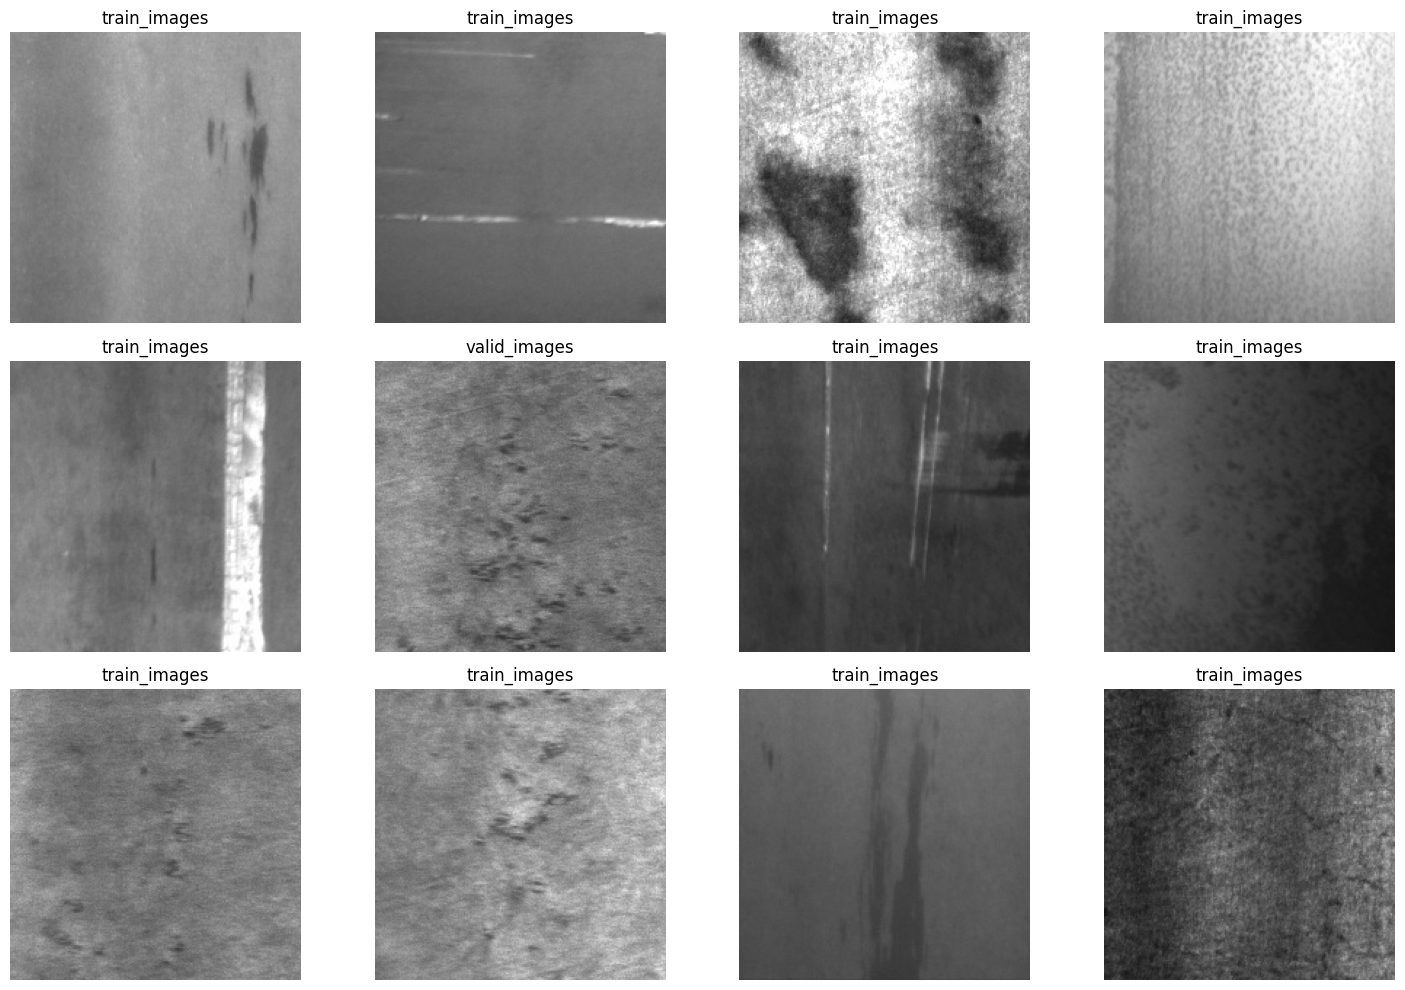

In [7]:
n_show = min(12, len(df))
sample_df = df.sample(n_show, random_state=SEED)

plt.figure(figsize=(15, 10))
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    image = cv2.imread(row["path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 4, i)
    plt.imshow(image)
    plt.title(row["class_name"])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Preprocessing: resize and grayscale

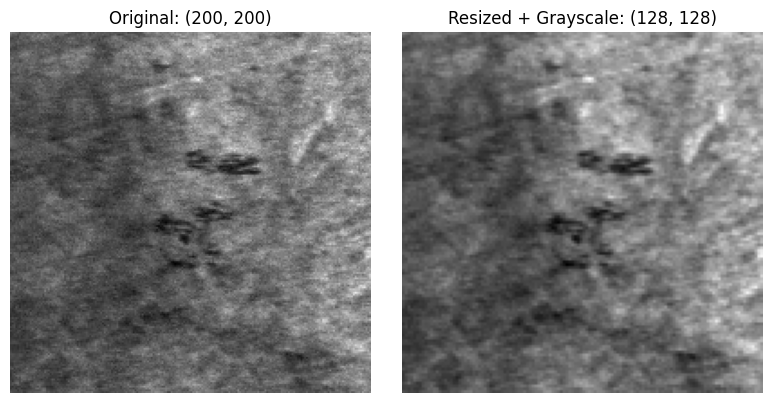

In [8]:
def preprocess_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    return image

sample_path = df.iloc[0]["path"]
sample_gray = preprocess_image(sample_path)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(original, cmap="gray")
plt.title(f"Original: {original.shape}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_gray, cmap="gray")
plt.title(f"Resized + Grayscale: {sample_gray.shape}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 9. HOG feature extraction function

In [9]:
def extract_hog(image, pixels_per_cell=(8, 8), orientations=9):
    features, hog_image = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True
    )
    return features, hog_image

## 10. Visualize the HOG representation

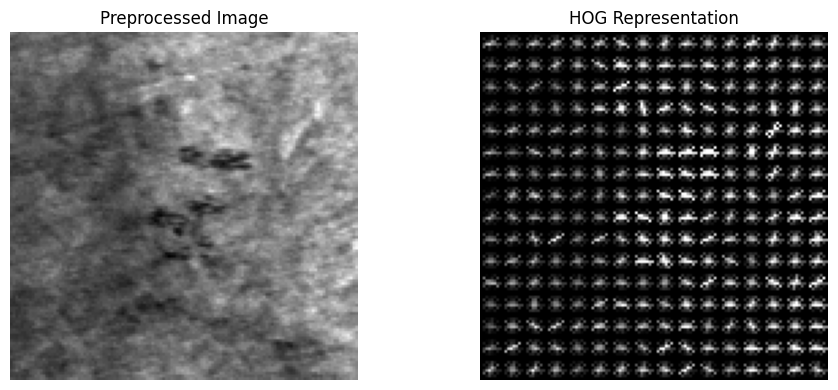

HOG feature vector length: 8100


In [10]:
features, hog_image = extract_hog(
    sample_gray,
    pixels_per_cell=(8, 8),
    orientations=9
)

hog_visual = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_gray, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_visual, cmap="gray")
plt.title("HOG Representation")
plt.axis("off")

plt.tight_layout()
plt.show()

print("HOG feature vector length:", len(features))

## 11. Extract HOG features for a dataframe

In [11]:
def create_hog_dataset(dataframe, pixels_per_cell=(8, 8), orientations=9):
    X = []
    y = []
    valid_paths = []

    for _, row in dataframe.iterrows():
        image = preprocess_image(row["path"])
        if image is None:
            continue

        feature_vector, _ = extract_hog(
            image,
            pixels_per_cell=pixels_per_cell,
            orientations=orientations
        )

        X.append(feature_vector)
        y.append(int(row["label"]))
        valid_paths.append(row["path"])

    return np.asarray(X, dtype=np.float32), np.asarray(y), valid_paths

X, y, valid_paths = create_hog_dataset(
    df,
    pixels_per_cell=(8, 8),
    orientations=9
)

print("Feature matrix:", X.shape)
print("Label vector:", y.shape)

Feature matrix: (1800, 8100)
Label vector: (1800,)


## 12. Train/test split



In [12]:
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))
print("Training class counts:", np.bincount(y_train))
print("Testing class counts:", np.bincount(y_test))

Training samples: 1440
Testing samples: 360
Training class counts: [1360   80]
Testing class counts: [340  20]


## 13. Train HOG + SVM

In [13]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        random_state=SEED
    ))
])

svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)

print("SVM training completed.")

SVM training completed.


## 14. Evaluate SVM

In [14]:
def multiclass_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

svm_metrics = multiclass_metrics(y_test, svm_predictions)

print("HOG + SVM")
print("=" * 40)
for k, v in svm_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    svm_predictions,
    labels=list(range(len(class_order))),
    target_names=class_order,
    zero_division=0
))

HOG + SVM
Accuracy  : 0.9444
Precision : 0.8920
Recall    : 0.9444
F1-Score  : 0.9175

Classification Report:
              precision    recall  f1-score   support

train_images       0.94      1.00      0.97       340
valid_images       0.00      0.00      0.00        20

    accuracy                           0.94       360
   macro avg       0.47      0.50      0.49       360
weighted avg       0.89      0.94      0.92       360



## 15. SVM confusion matrix

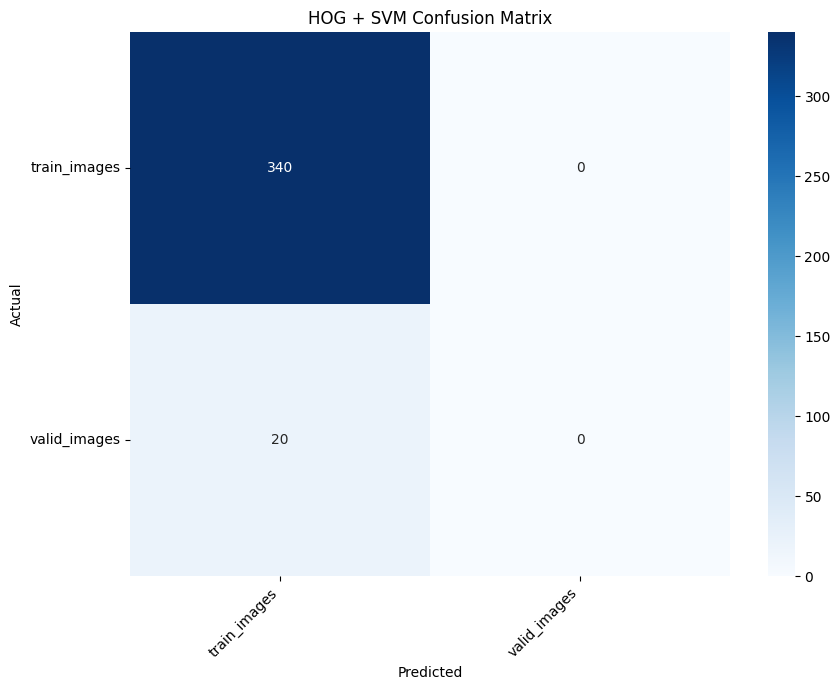

In [15]:
cm_svm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=list(range(len(class_order)))
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HOG + SVM Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Train HOG + Random Forest

Random Forest is the required additional machine-learning classifier.

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_metrics = multiclass_metrics(y_test, rf_predictions)

print("HOG + Random Forest")
print("=" * 40)
for k, v in rf_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    labels=list(range(len(class_order))),
    target_names=class_order,
    zero_division=0
))

HOG + Random Forest
Accuracy  : 0.9444
Precision : 0.8920
Recall    : 0.9444
F1-Score  : 0.9175

Classification Report:
              precision    recall  f1-score   support

train_images       0.94      1.00      0.97       340
valid_images       0.00      0.00      0.00        20

    accuracy                           0.94       360
   macro avg       0.47      0.50      0.49       360
weighted avg       0.89      0.94      0.92       360



## 17. Random Forest confusion matrix

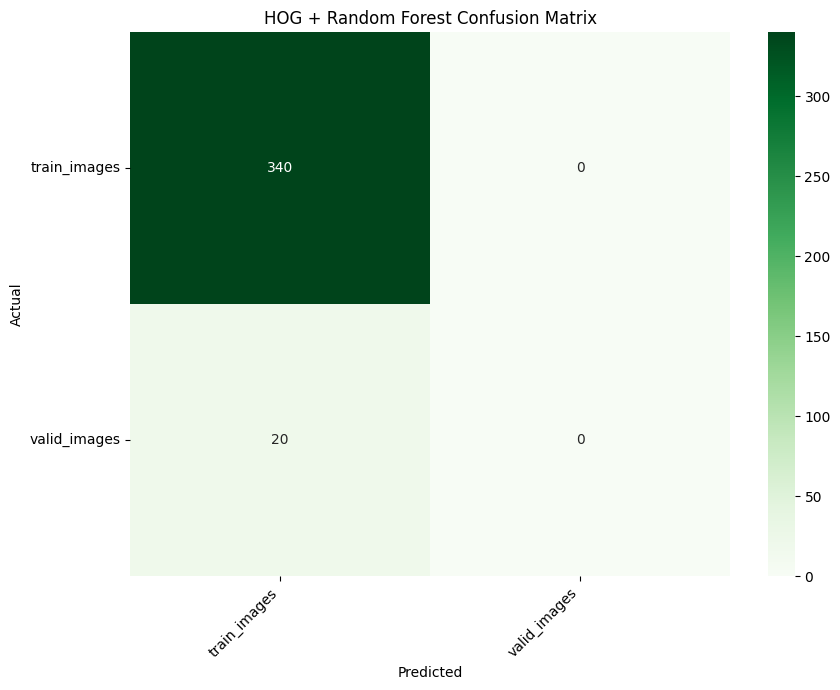

In [17]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions,
    labels=list(range(len(class_order)))
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_order,
    yticklabels=class_order
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HOG + Random Forest Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 18. Compare classifiers

In [18]:
classifier_results = pd.DataFrame([
    {"Classifier": "HOG + SVM", **svm_metrics},
    {"Classifier": "HOG + Random Forest", **rf_metrics}
])

display(classifier_results.round(4))

,Classifier,Accuracy,Precision,Recall,F1-Score
0,HOG + SVM,0.9444,0.892,0.9444,0.9175
1,HOG + Random Forest,0.9444,0.892,0.9444,0.9175


## 19. HOG parameter experiment: cell sizes 4×4, 8×8 and 16×16

The lab explicitly requires comparison of these three HOG cell sizes. To keep the experiment controlled, orientations are fixed at 9 and SVM is used for this parameter study.

In [19]:
cell_sizes = [(4, 4), (8, 8), (16, 16)]
cell_results = []

for cell_size in cell_sizes:
    print(f"Testing cell size {cell_size}...")

    X_param, y_param, _ = create_hog_dataset(
        df,
        pixels_per_cell=cell_size,
        orientations=9
    )

    idx = np.arange(len(y_param))
    tr, te = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_param
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            random_state=SEED
        ))
    ])

    model.fit(X_param[tr], y_param[tr])
    pred = model.predict(X_param[te])
    m = multiclass_metrics(y_param[te], pred)

    cell_results.append({
        "Cell Size": f"{cell_size[0]}x{cell_size[1]}",
        "Feature Length": X_param.shape[1],
        **m
    })

cell_results_df = pd.DataFrame(cell_results)
display(cell_results_df.round(4))

Testing cell size (4, 4)...
Testing cell size (8, 8)...
Testing cell size (16, 16)...


,Cell Size,Feature Length,Accuracy,Precision,Recall,F1-Score
0,4x4,34596,0.9444,0.892,0.9444,0.9175
1,8x8,8100,0.9444,0.892,0.9444,0.9175
2,16x16,1764,0.9444,0.892,0.9444,0.9175


## 20. HOG parameter experiment: orientations 6, 9 and 12

In [20]:
orientation_values = [6, 9, 12]
orientation_results = []

for orientation in orientation_values:
    print(f"Testing {orientation} orientations...")

    X_param, y_param, _ = create_hog_dataset(
        df,
        pixels_per_cell=(8, 8),
        orientations=orientation
    )

    idx = np.arange(len(y_param))
    tr, te = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_param
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            random_state=SEED
        ))
    ])

    model.fit(X_param[tr], y_param[tr])
    pred = model.predict(X_param[te])
    m = multiclass_metrics(y_param[te], pred)

    orientation_results.append({
        "Orientations": orientation,
        "Feature Length": X_param.shape[1],
        **m
    })

orientation_results_df = pd.DataFrame(orientation_results)
display(orientation_results_df.round(4))

Testing 6 orientations...
Testing 9 orientations...
Testing 12 orientations...


,Orientations,Feature Length,Accuracy,Precision,Recall,F1-Score
0,6,5400,0.9444,0.892,0.9444,0.9175
1,9,8100,0.9444,0.892,0.9444,0.9175
2,12,10800,0.9444,0.892,0.9444,0.9175


## 21. Plot HOG cell-size experiment

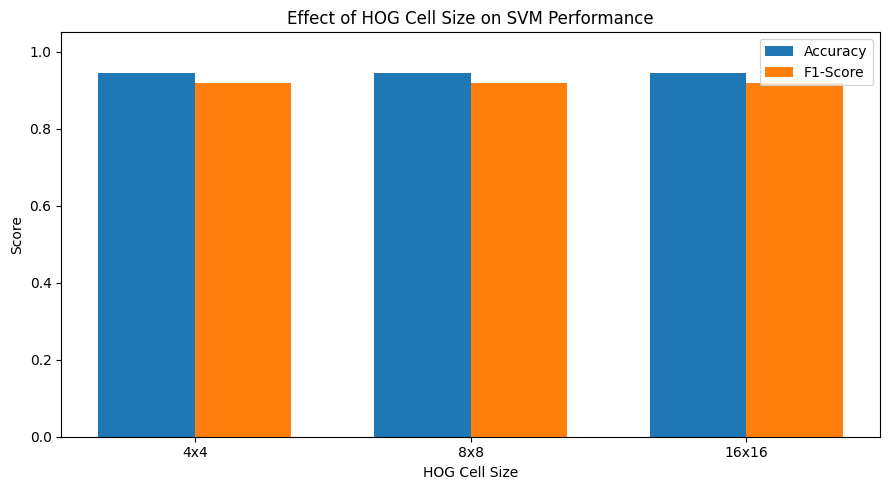

In [21]:
plt.figure(figsize=(9, 5))
x = np.arange(len(cell_results_df))
width = 0.35

plt.bar(
    x - width/2,
    cell_results_df["Accuracy"],
    width,
    label="Accuracy"
)
plt.bar(
    x + width/2,
    cell_results_df["F1-Score"],
    width,
    label="F1-Score"
)

plt.xticks(x, cell_results_df["Cell Size"])
plt.ylabel("Score")
plt.xlabel("HOG Cell Size")
plt.title("Effect of HOG Cell Size on SVM Performance")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 22. Plot HOG orientation experiment

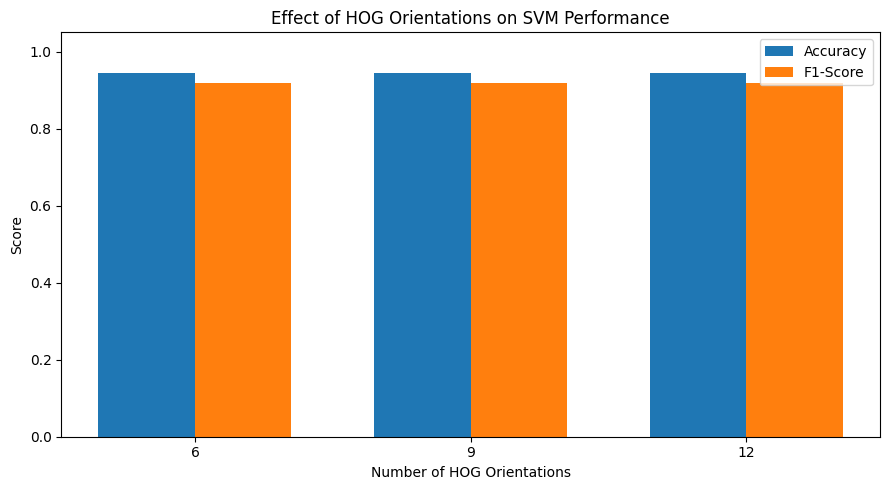

In [22]:
plt.figure(figsize=(9, 5))
x = np.arange(len(orientation_results_df))
width = 0.35

plt.bar(
    x - width/2,
    orientation_results_df["Accuracy"],
    width,
    label="Accuracy"
)
plt.bar(
    x + width/2,
    orientation_results_df["F1-Score"],
    width,
    label="F1-Score"
)

plt.xticks(x, orientation_results_df["Orientations"])
plt.ylabel("Score")
plt.xlabel("Number of HOG Orientations")
plt.title("Effect of HOG Orientations on SVM Performance")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 23. Select the best HOG configuration

The best configuration is selected by weighted F1-score, with accuracy as a secondary criterion.

In [23]:
combined_param_results = []

for _, row in cell_results_df.iterrows():
    combined_param_results.append({
        "Parameter": "Cell Size",
        "Configuration": row["Cell Size"],
        "Accuracy": row["Accuracy"],
        "F1-Score": row["F1-Score"]
    })

for _, row in orientation_results_df.iterrows():
    combined_param_results.append({
        "Parameter": "Orientations",
        "Configuration": str(int(row["Orientations"])),
        "Accuracy": row["Accuracy"],
        "F1-Score": row["F1-Score"]
    })

combined_param_results_df = pd.DataFrame(combined_param_results)
best_row = combined_param_results_df.sort_values(
    ["F1-Score", "Accuracy"],
    ascending=False
).iloc[0]

print("Best parameter result:")
print(best_row.to_string())

Best parameter result:
Parameter        Cell Size
Configuration          4x4
Accuracy          0.944444
F1-Score           0.91746


## 24. Robustness experiment



In [24]:
def transform_brightness(image):
    return cv2.convertScaleAbs(image, alpha=1.0, beta=45)

def transform_gaussian_noise(image):
    noise = np.random.normal(0, 20, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def transform_rotation(image):
    h, w = image.shape
    matrix = cv2.getRotationMatrix2D((w//2, h//2), 15, 1.0)
    return cv2.warpAffine(
        image,
        matrix,
        (w, h),
        borderMode=cv2.BORDER_REFLECT
    )

def transform_blur(image):
    return cv2.GaussianBlur(image, (7, 7), 0)

robustness_transforms = {
    "Brightness": transform_brightness,
    "Gaussian Noise": transform_gaussian_noise,
    "Rotation": transform_rotation,
    "Blur": transform_blur
}

## 25. Visualize robustness transformations

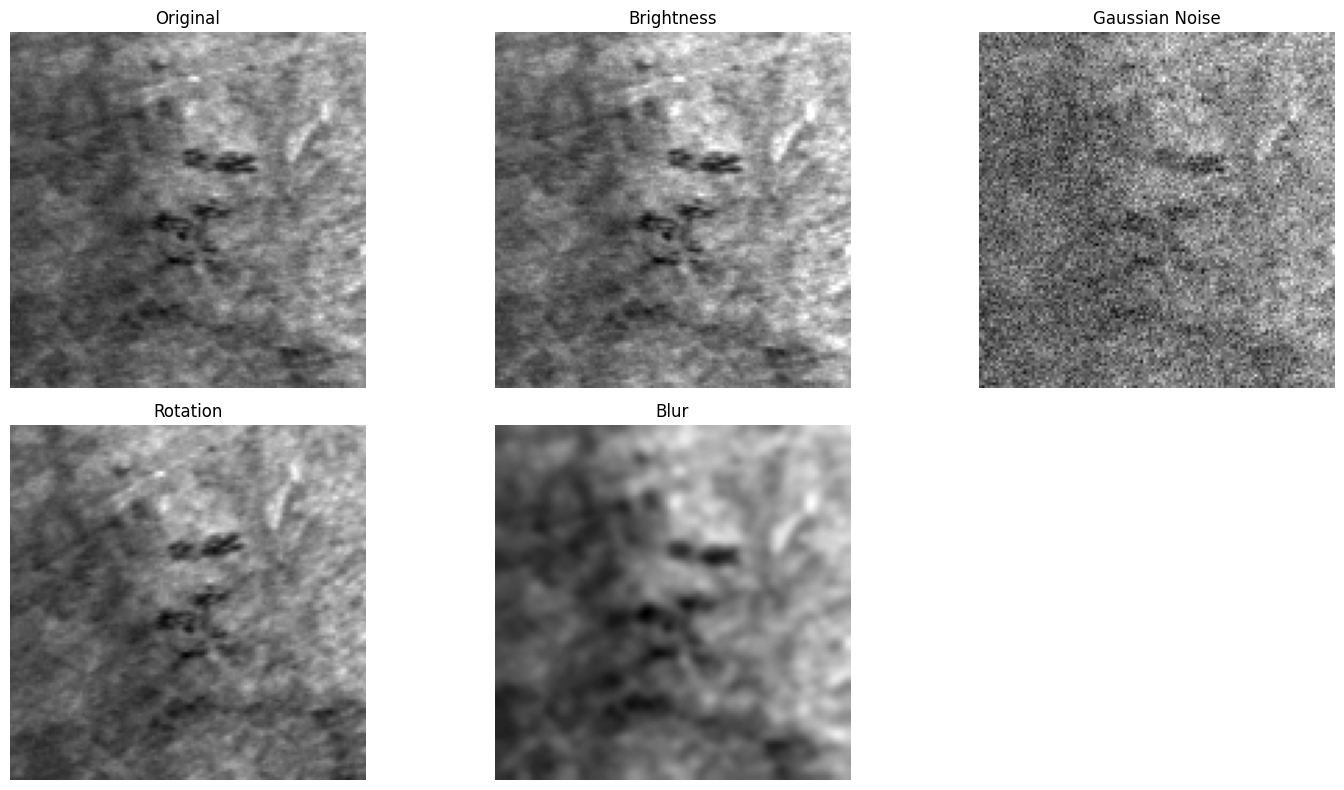

In [25]:
base_image = sample_gray.copy()

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(base_image, cmap="gray")
plt.title("Original")
plt.axis("off")

for i, (name, transform) in enumerate(robustness_transforms.items(), 2):
    plt.subplot(2, 3, i)
    plt.imshow(transform(base_image), cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 26. Evaluate robustness

In [26]:
def evaluate_transformed_dataset(model, dataframe, transform):
    preds = []
    true = []

    for _, row in dataframe.iterrows():
        image = preprocess_image(row["path"])
        if image is None:
            continue

        transformed = transform(image)
        feature_vector, _ = extract_hog(
            transformed,
            pixels_per_cell=(8, 8),
            orientations=9
        )

        pred = model.predict(feature_vector.reshape(1, -1))[0]
        preds.append(pred)
        true.append(int(row["label"]))

    return multiclass_metrics(np.asarray(true), np.asarray(preds))

robustness_results = []

for name, transform in robustness_transforms.items():
    print("Testing:", name)
    metrics = evaluate_transformed_dataset(
        svm_model,
        df.iloc[test_idx] if len(df) == len(y) else df,
        transform
    )
    robustness_results.append({
        "Condition": name,
        **metrics,
        "Accuracy Change": metrics["Accuracy"] - svm_metrics["Accuracy"],
        "F1 Change": metrics["F1-Score"] - svm_metrics["F1-Score"]
    })

robustness_df = pd.DataFrame(robustness_results)
display(robustness_df.round(4))

Testing: Brightness
Testing: Gaussian Noise
Testing: Rotation
Testing: Blur


,Condition,Accuracy,Precision,Recall,F1-Score,Accuracy Change,F1 Change
0,Brightness,0.9444,0.892,0.9444,0.9175,0.0,0.0
1,Gaussian Noise,0.9444,0.892,0.9444,0.9175,0.0,0.0
2,Rotation,0.9444,0.892,0.9444,0.9175,0.0,0.0
3,Blur,0.9444,0.892,0.9444,0.9175,0.0,0.0


## 27. Robustness accuracy and F1-score plot

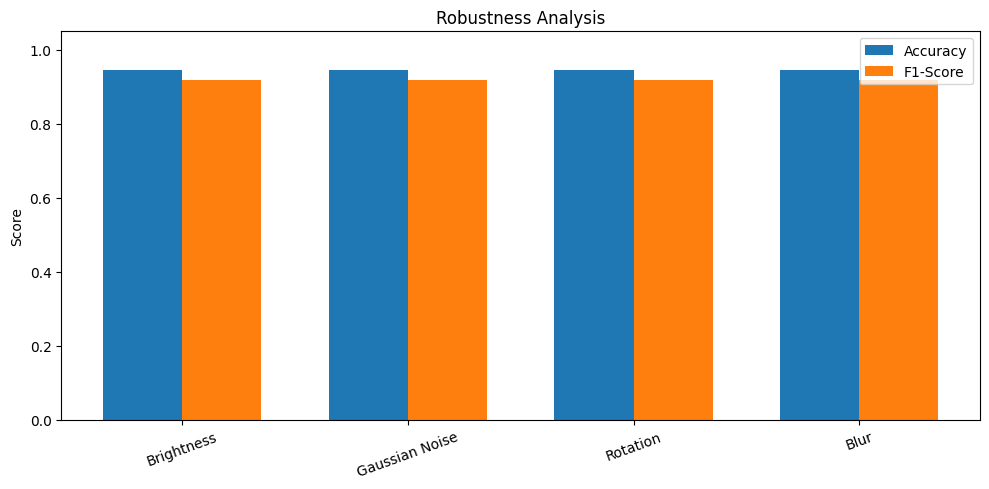

In [27]:
plt.figure(figsize=(10, 5))
x = np.arange(len(robustness_df))
width = 0.35

plt.bar(
    x - width/2,
    robustness_df["Accuracy"],
    width,
    label="Accuracy"
)
plt.bar(
    x + width/2,
    robustness_df["F1-Score"],
    width,
    label="F1-Score"
)

plt.xticks(x, robustness_df["Condition"], rotation=20)
plt.ylabel("Score")
plt.title("Robustness Analysis")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 28. Final industrial quality-control decision module



In [28]:
def inspect_product(image_path, model=svm_model):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    feature_vector, hog_image = extract_hog(
        image,
        pixels_per_cell=(8, 8),
        orientations=9
    )

    feature_vector = feature_vector.reshape(1, -1)
    prediction = int(model.predict(feature_vector)[0])

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(feature_vector)[0]
        confidence = float(np.max(probabilities)) * 100
    else:
        confidence = float("nan")

    predicted_class = class_order[prediction]
    is_normal_prediction = predicted_class in normal_names

    print("=" * 55)
    print("PRODUCT INSPECTION RESULT")
    print("=" * 55)

    if is_normal_prediction:
        print("Prediction :", "NON-DEFECTIVE")
        print(f"Class      : {predicted_class}")
        print(f"Confidence : {confidence:.2f}%")
        print("Action     :", "ACCEPT PRODUCT")
    else:
        print("Prediction :", "DEFECTIVE")
        print(f"Defect     : {predicted_class}")
        print(f"Confidence : {confidence:.2f}%")
        print("Action     :", "REJECT PRODUCT")

    print("=" * 55)

    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "decision": "ACCEPT PRODUCT" if is_normal_prediction else "REJECT PRODUCT"
    }

## 29. Test the final inspection module

In [29]:
inspection_result = inspect_product(df.iloc[0]["path"], svm_model)
inspection_result

PRODUCT INSPECTION RESULT
Prediction : DEFECTIVE
Defect     : train_images
Confidence : 93.88%
Action     : REJECT PRODUCT


{'prediction': 'train_images',
 'confidence': 93.87643679066983,
 'decision': 'REJECT PRODUCT'}

## 30. Inspect a random product

In [30]:
random_product = df.sample(1, random_state=123).iloc[0]

print("Testing image:")
print(random_product["path"])
print("Actual class:", random_product["class_name"])

inspect_product(random_product["path"], svm_model)

Testing image:
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1/train_images/patches_279.jpg
Actual class: train_images
PRODUCT INSPECTION RESULT
Prediction : DEFECTIVE
Defect     : train_images
Confidence : 95.57%
Action     : REJECT PRODUCT


{'prediction': 'train_images',
 'confidence': 95.56720379627504,
 'decision': 'REJECT PRODUCT'}

## 31. Save all experiment results


In [31]:
RESULT_DIR = WORK_DIR / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

classifier_results.to_csv(RESULT_DIR / "classifier_comparison.csv", index=False)
cell_results_df.to_csv(RESULT_DIR / "hog_cell_size_results.csv", index=False)
orientation_results_df.to_csv(RESULT_DIR / "hog_orientation_results.csv", index=False)
robustness_df.to_csv(RESULT_DIR / "robustness_results.csv", index=False)

dataset_summary = pd.DataFrame({
    "Class": class_order,
    "Image Count": [int((df["class_name"] == c).sum()) for c in class_order]
})
dataset_summary.to_csv(RESULT_DIR / "dataset_summary.csv", index=False)

print("Results saved to:", RESULT_DIR)
print("\nFiles:")
for p in sorted(RESULT_DIR.iterdir()):
    print("-", p.name)

Results saved to: /content/lab05_hog/results

Files:
- classifier_comparison.csv
- dataset_summary.csv
- hog_cell_size_results.csv
- hog_orientation_results.csv
- robustness_results.csv


## 32. Save important figures

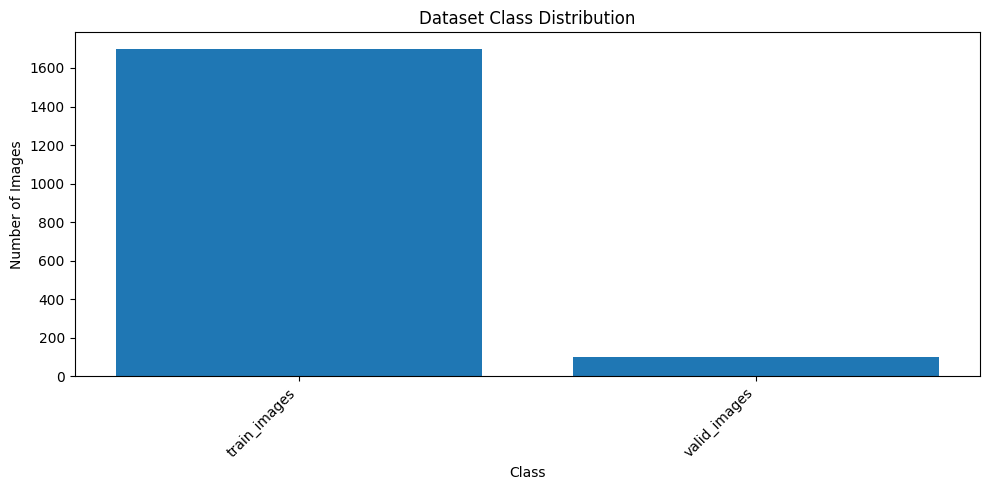

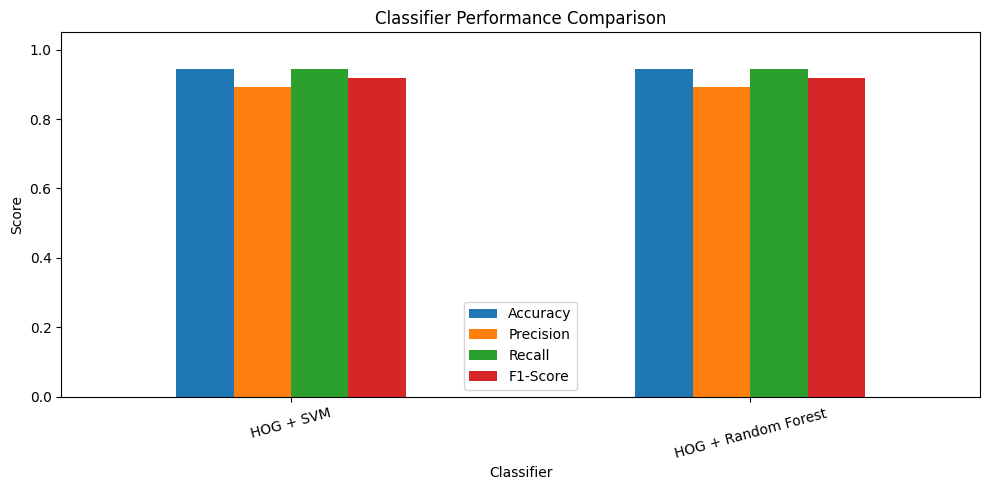

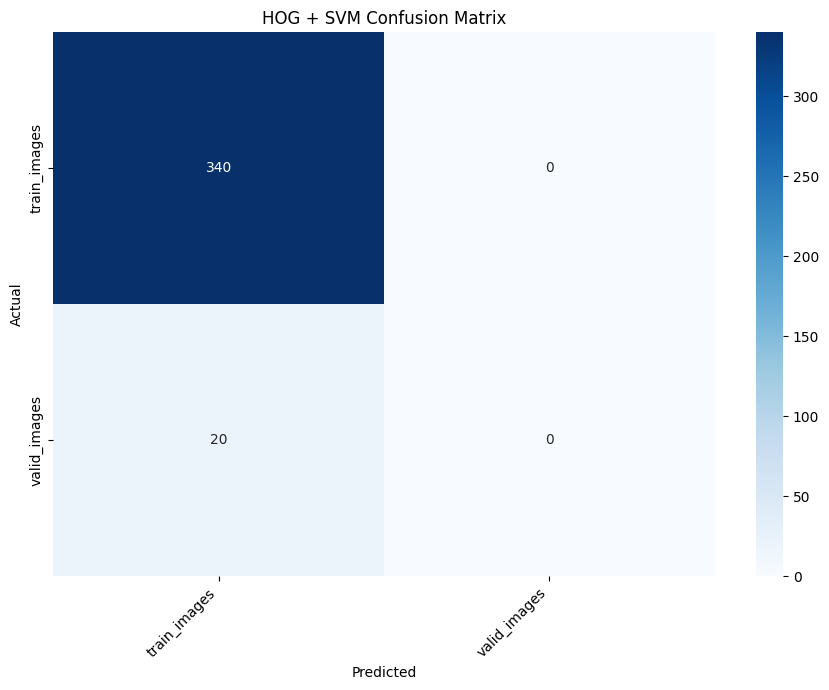

Figures saved to: /content/lab05_hog/figures


In [32]:
FIG_DIR = WORK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Class distribution
plt.figure(figsize=(10, 5))
counts = df["class_name"].value_counts().reindex(class_order)
plt.bar(counts.index, counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "dataset_distribution.png", dpi=200)
plt.show()

# Classifier comparison
plt.figure(figsize=(10, 5))
plot_df = classifier_results.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1-Score"]]
plot_df.plot(kind="bar", ax=plt.gca())
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "classifier_comparison.png", dpi=200)
plt.show()

# SVM confusion matrix
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HOG + SVM Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "svm_confusion_matrix.png", dpi=200)
plt.show()

print("Figures saved to:", FIG_DIR)

# 33. Final summary

This notebook implements the complete non-bonus Lab 05 workflow:

- Dataset loading and inspection
- Common-size resizing
- Grayscale preprocessing
- HOG feature extraction
- HOG visualization
- SVM classifier
- Random Forest classifier
- Classifier comparison
- Confusion matrices
- Classification reports
- Accuracy, precision, recall and F1-score
- HOG cell-size comparison: 4×4, 8×8, 16×16
- HOG orientation comparison: 6, 9, 12
- Robustness testing: brightness, Gaussian noise, rotation and blur
- Accuracy/F1 robustness changes
- Final industrial ACCEPT/REJECT decision
- CSV and PNG result export

